In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import cv2

from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.applications import  MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from livelossplot import PlotLossesKeras
from tensorflow.keras.callbacks import CSVLogger

In [4]:
pip install livelossplot

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
pip install split-folders

# **Splitting the Dataset Folder**

In [ ]:
import splitfolders

# Path to your main folder containing disease subfolders
input_folder = "/content/drive/MyDrive/Colab/IMG_CLASSES"

# Path where you want the split folders to be created
output_folder = "/content/drive/MyDrive/Colab/splitted_data_folder"

# Split with a ratio (train, val, test) or just (train, test)
# Use ratio=(.7, .15, .15) for an 70/15/15 train/test/val split


splitfolders.ratio(input_folder, output=output_folder, seed=1000, ratio=(.7,.15,.15))

# **Total Number of Files in each Class**

In [ ]:
dataset_path =  "/content/drive/MyDrive/Colab/IMG_CLASSES"

classes = os.listdir(dataset_path)

for c in classes:
    print(c, len(os.listdir(os.path.join(dataset_path, c))))

Warts Molluscum and other Viral Infections 2113
Tinea Ringworm Candidiasis and other Fungal Infections 1703
Seborrheic Keratoses and other Benign Tumors 1847
Psoriasis pictures Lichen Planus and Related Diseases 2055
Melanoma 3140
Eczema 1677
Melanocytic Nevi (NV) 7971
Benign Keratosis-like Lesions (BKL) 2079
Basal Cell Carcinoma (BCC) 3324
Atopic Dermatitis 1389


In [ ]:
classes = os.listdir(dataset_path)
class_counts =[len(os.listdir(dataset_path + '/' + x)) for x in classes]
print("Class counts:", class_counts)

Class counts: [2113, 1703, 1847, 2055, 3140, 1677, 7971, 2079, 3324, 1389]


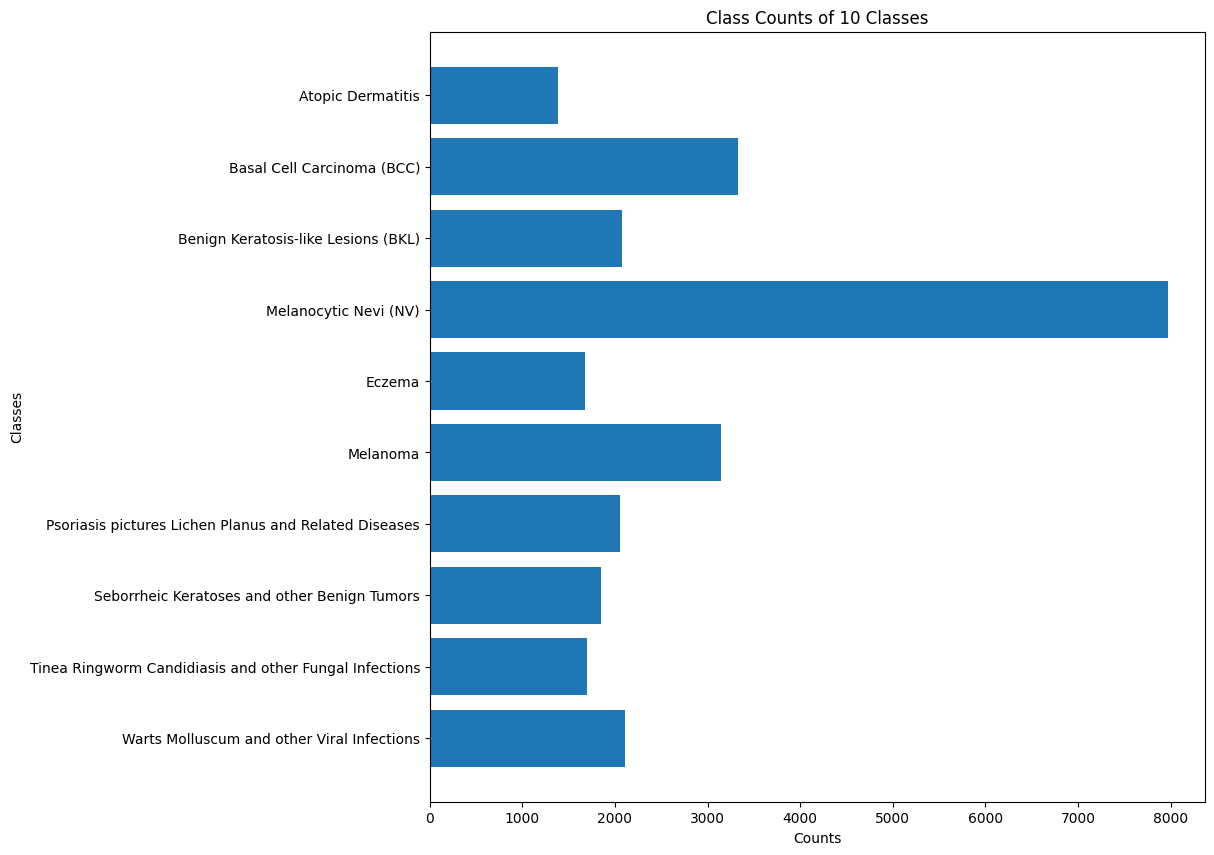

In [ ]:
# Visualize class counts
plt.figure(figsize=(10, 10))
bars = plt.barh(classes, class_counts)
plt.xlabel('Counts')
plt.ylabel('Classes')
plt.title('Class Counts of 10 Classes')
plt.show()

# **Trainning Folder**

In [7]:
dataset_path_train = "/content/drive/MyDrive/Colab/splitted_data_folder/train"

classes_train = os.listdir(dataset_path_train)

for c in classes_train:
    print(c, len(os.listdir(os.path.join(dataset_path_train, c))))

Warts Molluscum and other Viral Infections 1479
Tinea Ringworm Candidiasis and other Fungal Infections 1192
Seborrheic Keratoses and other Benign Tumors 1292
Psoriasis pictures Lichen Planus and Related Diseases 1438
Melanoma 2198
Eczema 1173
Melanocytic Nevi (NV) 5579
Benign Keratosis-like Lesions (BKL) 1455
Basal Cell Carcinoma (BCC) 2326
Atopic Dermatitis 972


# **Test Folder**

In [8]:
dataset_path_test =  "/content/drive/MyDrive/Colab/splitted_data_folder/test"

classes_test = os.listdir(dataset_path_test)

for c in classes_test:
    print(c, len(os.listdir(os.path.join(dataset_path_test, c))))

Warts Molluscum and other Viral Infections 318
Tinea Ringworm Candidiasis and other Fungal Infections 256
Seborrheic Keratoses and other Benign Tumors 278
Psoriasis pictures Lichen Planus and Related Diseases 309
Melanoma 471
Eczema 253
Melanocytic Nevi (NV) 1197
Benign Keratosis-like Lesions (BKL) 313
Basal Cell Carcinoma (BCC) 500
Atopic Dermatitis 209


# **Validation Folder**

In [9]:
dataset_path_test =  "/content/drive/MyDrive/Colab/splitted_data_folder/val"

classes_val = os.listdir(dataset_path_test)

for c in classes_test:
    print(c, len(os.listdir(os.path.join(dataset_path_test, c))))

Warts Molluscum and other Viral Infections 316
Tinea Ringworm Candidiasis and other Fungal Infections 255
Seborrheic Keratoses and other Benign Tumors 277
Psoriasis pictures Lichen Planus and Related Diseases 308
Melanoma 471
Eczema 251
Melanocytic Nevi (NV) 1195
Benign Keratosis-like Lesions (BKL) 311
Basal Cell Carcinoma (BCC) 498
Atopic Dermatitis 208


# **Visualizing Random Skin Disease Image from Train Folder**

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

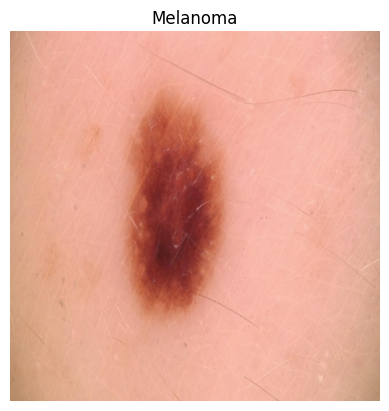

In [50]:
import random

class_name = random.choice(classes_train)
img_path = os.path.join(dataset_path_train, class_name,
                        random.choice(os.listdir(os.path.join(dataset_path_train,class_name))))

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title(class_name)
plt.axis("off")

In [11]:
train_data = "/content/drive/MyDrive/Colab/splitted_data_folder/train"
test_data = "/content/drive/MyDrive/Colab/splitted_data_folder/test"
val_data = "/content/drive/MyDrive/Colab/splitted_data_folder/val"

In [12]:
# Define paths (already available from previous cells)
train_data_path = train_data
test_data_path = test_data
val_data_path = val_data

# Function to create dataframe from directory structure
def create_dataframe(data_dir):
    filepaths = []
    labels = []
    for class_name in os.listdir(data_dir):
        class_path = os.path.join(data_dir, class_name)
        if os.path.isdir(class_path): # Ensure it's a directory, not a file
            for img_name in os.listdir(class_path):
                filepaths.append(os.path.join(class_path, img_name))
                labels.append(class_name)
    return pd.DataFrame({'filepaths': filepaths, 'labels': labels})

# Create dataframes for train, test, and validation sets
train_df = create_dataframe(train_data_path)
test_df = create_dataframe(test_data_path)
val_df = create_dataframe(val_data_path)

In [13]:
TARGET_SIZE = (224, 224)
BATCH_SIZE  = 32

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
train_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.15,
    shear_range=0.1,
    fill_mode='nearest'
)

val_test_gen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_gen.flow_from_dataframe(
    dataframe=train_df,
    x_col='filepaths',
    y_col='labels',
    target_size=TARGET_SIZE,
    color_mode='rgb',
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_generator = val_test_gen.flow_from_dataframe(
    dataframe=val_df,
    x_col='filepaths',
    y_col='labels',
    target_size=TARGET_SIZE,
    color_mode='rgb',
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_generator = val_test_gen.flow_from_dataframe(
    dataframe=test_df,
    x_col='filepaths',
    y_col='labels',
    target_size=TARGET_SIZE,
    color_mode='rgb',
    class_mode='categorical',
    batch_size=BATCH_SIZE,
    shuffle=False
)


Found 19104 validated image filenames belonging to 10 classes.
Found 4090 validated image filenames belonging to 10 classes.
Found 4104 validated image filenames belonging to 10 classes.


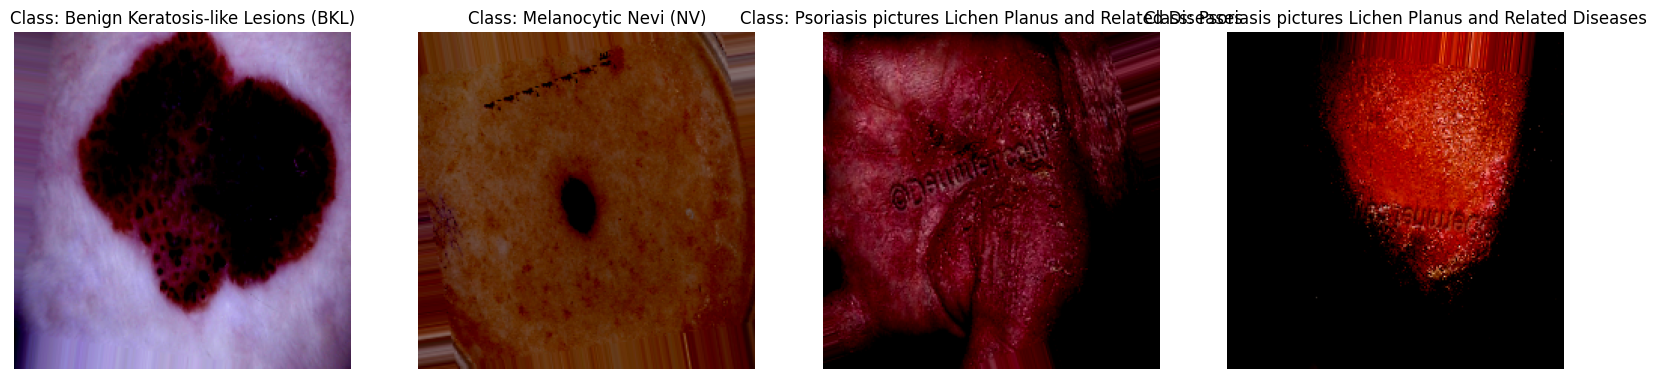

In [14]:
# Get a batch of images and labels
images, labels = next(train_generator)

# The 'images' array has a shape of (batch_size, target_size[0], target_size[1], channels)

# Display the first few images from the batch
fig, axes = plt.subplots(1, 4, figsize=(20, 20))
axes = axes.flatten()

for i in range(4):
    img = images[i]
    ax = axes[i]
    ax.imshow(img)

    label_index = np.argmax(labels[i])
    class_name = list(train_generator.class_indices.keys())[label_index]
    ax.set_title(f"Class: {class_name}")

    ax.axis('off') # Hide axis
plt.show();

###

In [15]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(train_df['labels'])
weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_df['labels']
)

class_weight_dict = {
    train_generator.class_indices[c]: w
    for c, w in zip(classes, weights)
}
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(1.9654320987654321), 1: np.float64(0.8213241616509028), 2: np.float64(1.3129896907216494), 3: np.float64(1.6286445012787725), 4: np.float64(0.34242695823624303), 5: np.float64(0.8691537761601456), 6: np.float64(1.3285118219749652), 7: np.float64(1.4786377708978329), 8: np.float64(1.6026845637583893), 9: np.float64(1.291683569979716)}


In [16]:
train_generator.class_indices

{'Atopic Dermatitis': 0,
 'Basal Cell Carcinoma (BCC)': 1,
 'Benign Keratosis-like Lesions (BKL)': 2,
 'Eczema': 3,
 'Melanocytic Nevi (NV)': 4,
 'Melanoma': 5,
 'Psoriasis pictures Lichen Planus and Related Diseases': 6,
 'Seborrheic Keratoses and other Benign Tumors': 7,
 'Tinea Ringworm Candidiasis and other Fungal Infections': 8,
 'Warts Molluscum and other Viral Infections': 9}

In [17]:
NUM_CLASSES = len(train_generator.class_indices)
NUM_CLASSES

10

In [18]:

base_model = MobileNetV2(weights='imagenet',
                         include_top=False,
                         input_shape=(224, 224, 3))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [19]:

NUM_CLASSES = len(train_generator.class_indices)
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)

x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)

predictions = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

###comment: change the loss to categoricalcrossentropy and also make the learning rate lower to avoid destroying your pretrained weights
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

model.summary()




Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,049,802 (11.63 MB)

 Trainable params: 790,794 (3.02 MB)

 Non-trainable params: 2,259,008 (8.62 MB)

In [20]:
# Path to a folder in your Drive
checkpoint_path = "/content/drive/MyDrive/Colab/models/cp-{epoch:04d}.weights.h5"

cp_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    verbose=1,
    save_weights_only=True,
    save_freq='epoch') # Saves at the end of every epoch


In [ ]:
# Path to your specific checkpoint
checkpoint_path = "/content/drive/MyDrive/Colab/models/cp-0000.weights.h5"

# Load the weights into the compiled model
model.load_weights(checkpoint_path)
print("Weights loaded! Ready to continue training.")

Weights loaded! Ready to continue training.


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [21]:
###comment: Now define your model checkpoint, earlystopping and reduceplatea in a callback

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=checkpoint_path,
        verbose=1,
        save_weights_only=True,
        save_freq='epoch'
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )
]



In [22]:
csv_logger = CSVLogger('/content/drive/MyDrive/Colab/trainning_history.csv', append=True)

In [24]:
### comment: Train here
initial_epoch_to_start = 0


history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=20,
    class_weight=class_weight_dict,
    initial_epoch=initial_epoch_to_start,
    callbacks=[callbacks,csv_logger, PlotLossesKeras()]
)

In [ ]:
model_save_path = '/content/drive/MyDrive/my_model.keras'
model.save(model_save_path)

In [ ]:
model.evaluate(val_generator)

128/128 ━━━━━━━━━━━━━━━━━━━━ 1049s 8s/step - accuracy: 0.6758 - loss: 1.1807


[1.1807464361190796, 0.6757946014404297]

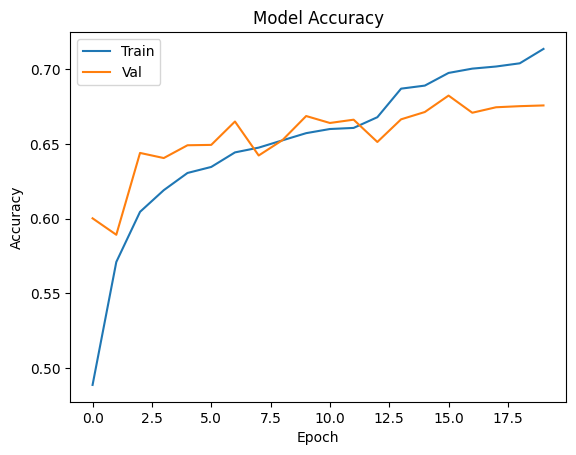

In [25]:
log_data = pd.read_csv('/content/drive/MyDrive/Colab/trainning_history.csv')

# Plot the combined accuracy
plt.plot(log_data['accuracy'])
plt.plot(log_data['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Val'], loc='upper left')
plt.show()

In [26]:
# Get class names
class_names = list(test_generator.class_indices.keys())

class_names

['Atopic Dermatitis',
 'Basal Cell Carcinoma (BCC)',
 'Benign Keratosis-like Lesions (BKL)',
 'Eczema',
 'Melanocytic Nevi (NV)',
 'Melanoma',
 'Psoriasis pictures Lichen Planus and Related Diseases',
 'Seborrheic Keratoses and other Benign Tumors',
 'Tinea Ringworm Candidiasis and other Fungal Infections',
 'Warts Molluscum and other Viral Infections']

In [ ]:
# Predict the labels

Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)

# Get true labels
y_true = test_generator.classes

# Calculate Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

#Generate Classification Report (Precision, Recall, F1)
report = classification_report(y_true, y_pred, target_names=class_names)
print("Classification Report:\n")
print(report)

129/129 ━━━━━━━━━━━━━━━━━━━━ 905s 7s/step
Classification Report:

                                                        precision    recall  f1-score   support

                                     Atopic Dermatitis       0.48      0.53      0.50       209
                            Basal Cell Carcinoma (BCC)       0.83      0.76      0.79       500
                   Benign Keratosis-like Lesions (BKL)       0.46      0.77      0.58       313
                                                Eczema       0.46      0.59      0.52       253
                                 Melanocytic Nevi (NV)       0.91      0.79      0.85      1197
                                              Melanoma       0.83      0.84      0.83       471
 Psoriasis pictures Lichen Planus and Related Diseases       0.55      0.31      0.40       309
          Seborrheic Keratoses and other Benign Tumors       0.58      0.67      0.63       278
Tinea Ringworm Candidiasis and other Fungal Infections       0.50    

In [ ]:
model_save_path = '/content/drive/MyDrive/my_model.keras'
model.save(model_save_path)

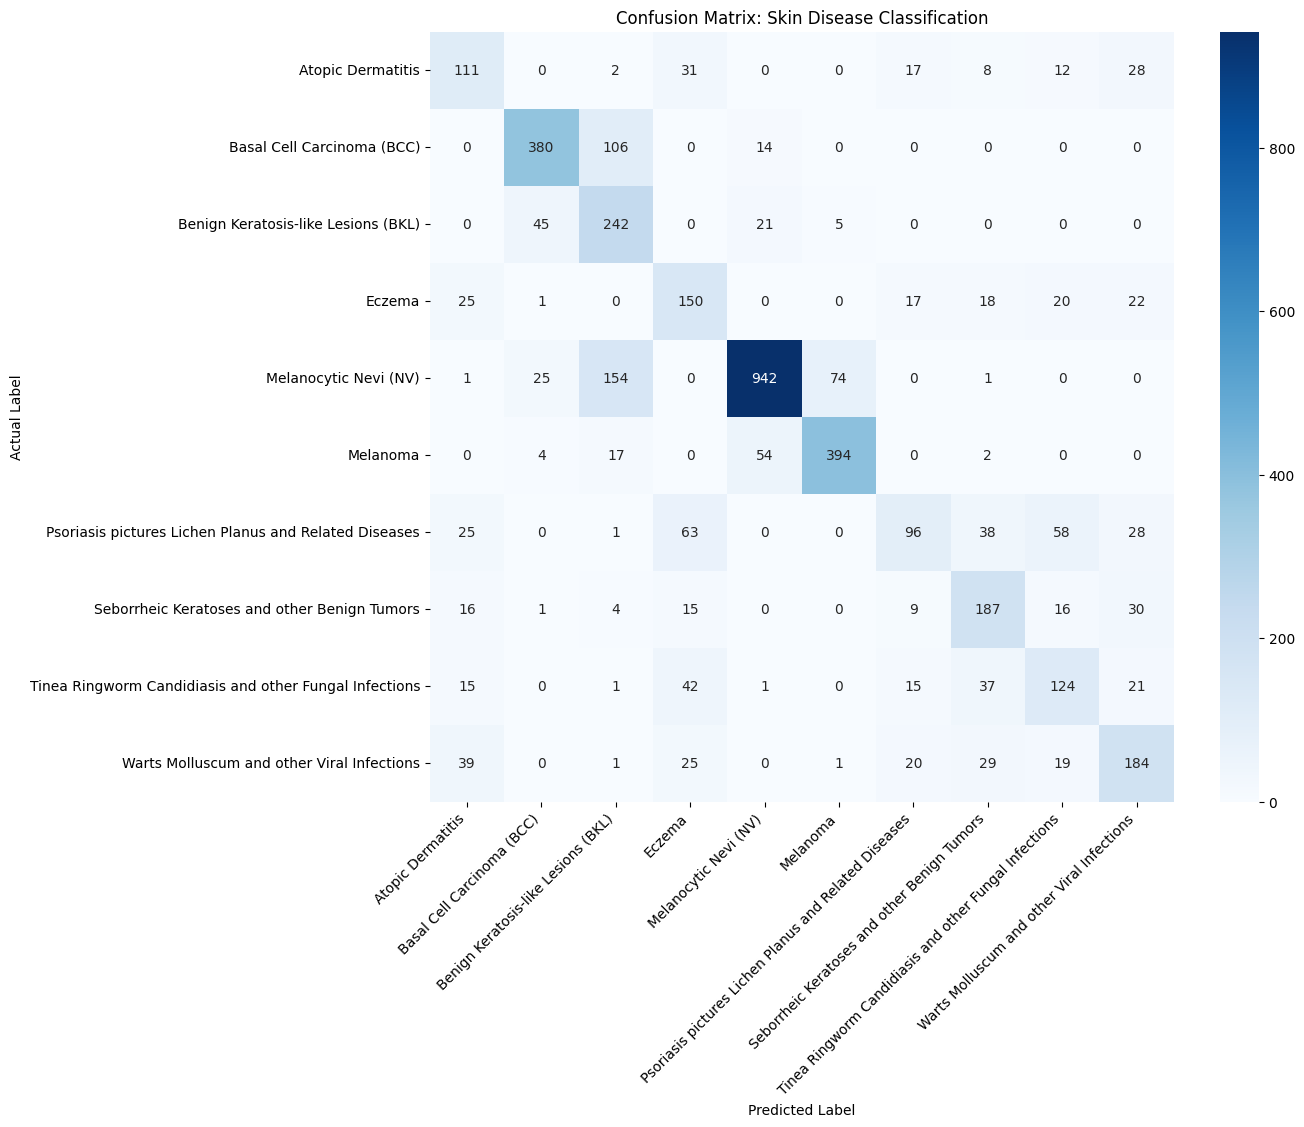

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix: Skin Disease Classification')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.show()

In [51]:
model_path = "/content/drive/MyDrive/Colab/my_model01.keras"

tf.keras.models.load_model(model_path)

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 18 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


<Functional name=functional, built=True>

In [52]:
CLASS_NAMES = {
    0: "Atopic Dermatitis",
    1: "Basal Cell Carcinoma (BCC)",
    2: "Benign Keratosis-like Lesions (BKL)",
    3: "Eczema",
    4: "Melanocytic Nevi (NV)",
    5: "Melanoma",
    6: "Psoriasis, Lichen Planus and Related Diseases",
    7: "Seborrheic Keratoses and other Benign Tumors",
    8: "Tinea Ringworm Candidiasis and other Fungal Infections",
    9: "Warts Molluscum and other Viral Infections"
}

In [53]:
import cv2

image_path = "/content/drive/MyDrive/Colab/sample_image/ISIC_6653780.jpg"

# Load the image using cv2
img = cv2.imread(image_path)
# Convert from BGR to RGB
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Resize the image
img_processed = cv2.resize(img, (224, 224))

# EXACT same preprocessing as your training script
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
img_array = np.array(img_processed)
img_array = np.expand_dims(img_array, axis=0)
img_array = preprocess_input(img_array) # This replaces the /255.0


# Prediction
prediction = model.predict(img_array)
predicted_class_idx = np.argmax(prediction)


result = CLASS_NAMES.get(predicted_class_idx)

result

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


'Tinea Ringworm Candidiasis and other Fungal Infections'